# Vision Transformer backbone — Group 9 OOD case study

Explainable Out-of-Distribution Detection for Foreign Object Rejection in Automated Fruit and Vegetable Grading Systems (TR-6 dataset).

This notebook implements the **Vision Transformer** box from the architecture diagram: a pretrained ViT fine-tuned on the 5 in-distribution classes for one leave-one-class-out fold, producing the pooled `[CLS]` embeddings that feed the shared "feature embeddings" merge point, plus raw attention weights for the attention-rollout explainability step.

Deliberately **out of scope here** (follow-up work): rotating the held-out class across all 6 folds, the SSL-pretrained CNN and supervised CNN backbones, attention-rollout implementation, and the energy score / MSP / prototype-distance OOD scorers.

In [14]:
import os

# hf_xet (the default fast-transfer client in huggingface_hub>=1.x) hangs on this
# network — plain HTTPS downloads work fine, so force that path before importing
# anything from transformers/huggingface_hub.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm
from transformers import ViTModel, ViTImageProcessor

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## Config

In [15]:
NOTEBOOK_DIR = Path.cwd()
DATA_ROOT = (NOTEBOOK_DIR / ".." / ".." / "TR-6 copy").resolve()
if not DATA_ROOT.exists():
    DATA_ROOT = (NOTEBOOK_DIR / ".." / "TR-6 copy").resolve()
assert DATA_ROOT.exists(), f"TR-6 dataset not found (looked near {NOTEBOOK_DIR})"

CLASSES = ["Banana", "Carrot", "Guava", "Indian_Gooseberry", "Mango", "Tomato"]
HELD_OUT_CLASS = "Mango"  # rotate this across all 6 classes for the full leave-one-class-out protocol later
KNOWN_CLASSES = [c for c in CLASSES if c != HELD_OUT_CLASS]

PRETRAINED_CKPT = "google/vit-base-patch16-224-in21k"
IMAGE_SIZE = 224
BATCH_SIZE = 32
VAL_FRACTION = 0.2
EPOCHS = 5
FREEZE_BACKBONE = True  # linear-probe the pretrained ViT; set False to fine-tune the whole backbone

# Set to a small number (e.g. 20) for a quick end-to-end smoke run; None uses every image.
MAX_IMAGES_PER_CLASS = 300

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Data root:        {DATA_ROOT}")
print(f"Known classes:    {KNOWN_CLASSES}")
print(f"Held-out (OOD):   {HELD_OUT_CLASS}")
print(f"Device:           {DEVICE}")

Data root:        /home/adarssh/dev/NNDL/TR-6 copy
Known classes:    ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Tomato']
Held-out (OOD):   Mango
Device:           cuda


## Dataset scanning

Uses the sRGB images under `Normal/<class>/sRGB_images` (the `Classified/` branch holds the
same images re-sorted into Spoiled/Not_spoiled, so reading both would double-count).

Filenames are `YYYYMMDD_HHMMSS.jpg` with no explicit specimen ID. Per the report's
leakage warning (fruit photographed repeatedly across its whole decomposition period),
we group images by **capture day** as the finest specimen/session proxy available, and
split train/val by group — never by individual image — so the same day's photos of a
fruit can't land on both sides of the split.

In [16]:
def scan_class_images(data_root: Path, class_name: str, limit: int | None = None) -> list[Path]:
    folder = data_root / "Normal" / class_name / "sRGB_images"
    paths = sorted(folder.glob("*.jpg"))
    return paths[:limit] if limit else paths


def session_id(image_path: Path, class_name: str) -> str:
    """Capture-day + class as the specimen/session grouping key (see markdown above)."""
    day = image_path.stem.split("_")[0]
    return f"{class_name}_{day}"


class_images = {c: scan_class_images(DATA_ROOT, c, MAX_IMAGES_PER_CLASS) for c in CLASSES}
for c, paths in class_images.items():
    n_days = len({session_id(p, c) for p in paths})
    print(f"{c:20s} {len(paths):5d} images  {n_days:3d} capture days")

Banana                 150 images    3 capture days
Carrot                 150 images    3 capture days
Guava                  150 images    3 capture days
Indian_Gooseberry      150 images    3 capture days
Mango                  150 images    3 capture days
Tomato                 150 images    3 capture days


## Leave-one-class-out split (this fold)

5 known classes are group-split into train/val by capture day; the held-out class is
never touched by the split — it exists purely as the OOD test proxy. Both isolation
properties are asserted explicitly rather than eyeballed, per the report's requirement
that this be a real verification step.

In [17]:
train_samples, val_samples = [], []
train_groups_all, val_groups_all = set(), set()

for label, class_name in enumerate(KNOWN_CLASSES):
    paths = class_images[class_name]
    groups = [session_id(p, class_name) for p in paths]
    splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    train_idx, val_idx = next(splitter.split(paths, groups=groups))

    train_samples += [(paths[i], label) for i in train_idx]
    val_samples += [(paths[i], label) for i in val_idx]
    train_groups_all.update(groups[i] for i in train_idx)
    val_groups_all.update(groups[i] for i in val_idx)

assert train_groups_all.isdisjoint(val_groups_all), "Session leakage between train/val!"
print("Train/val session isolation verified: zero overlap.")

ood_samples = [(p, -1) for p in class_images[HELD_OUT_CLASS]]  # label unused — held out entirely

train_val_paths = {p for p, _ in train_samples + val_samples}
ood_paths = {p for p, _ in ood_samples}
assert train_val_paths.isdisjoint(ood_paths), "Held-out class leaked into train/val!"
print("Held-out class isolation verified: zero overlap.")

print(f"\nTrain: {len(train_samples)} images")
print(f"Val:   {len(val_samples)} images")
print(f"OOD:   {len(ood_samples)} images (held-out class: {HELD_OUT_CLASS})")

Train/val session isolation verified: zero overlap.
Held-out class isolation verified: zero overlap.

Train: 495 images
Val:   255 images
OOD:   150 images (held-out class: Mango)


## Class imbalance

Per-class counts are heavily skewed (e.g. Tomato vs. Banana), so the classification
loss is weighted by inverse train-set frequency.

In [18]:
label_counts = Counter(label for _, label in train_samples)
class_weights = torch.tensor(
    [len(train_samples) / (len(KNOWN_CLASSES) * label_counts[i]) for i in range(len(KNOWN_CLASSES))],
    dtype=torch.float32,
)
for c, w in zip(KNOWN_CLASSES, class_weights.tolist()):
    print(f"{c:20s} weight={w:.3f}")

Banana               weight=1.000
Carrot               weight=1.000
Guava                weight=1.000
Indian_Gooseberry    weight=1.000
Tomato               weight=1.000


## Model

Wraps a pretrained ViT (`google/vit-base-patch16-224-in21k`) so it can serve the three
roles the architecture diagram needs from this backbone:

- `forward` — classification logits over the 5 known classes (fine-tuning).
- `get_embeddings` — the pooled `[CLS]` token, i.e. what lands in the shared
  feature-embedding merge point.
- `get_attentions` — per-layer attention weights, earmarked for attention-rollout
  explainability in a later step (not implemented here). Loaded with
  `attn_implementation="eager"` since the default `sdpa` backend can't return
  attention weights.

Backbone is frozen by default (linear probe) — only the classification head trains.

In [8]:
class ViTBackbone(nn.Module):
    def __init__(self, checkpoint: str, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        self.vit = ViTModel.from_pretrained(checkpoint, add_pooling_layer=True, attn_implementation="eager")
        hidden_size = self.vit.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_classes)

        if freeze_backbone:
            for param in self.vit.parameters():
                param.requires_grad = False

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        return self.classifier(outputs.pooler_output)

    @torch.no_grad()
    def get_embeddings(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        return outputs.pooler_output

    @torch.no_grad()
    def get_attentions(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values, output_attentions=True)
        return outputs.attentions  # tuple of (batch, heads, tokens, tokens), one per layer

## Preprocessing + data loaders

In [20]:
processor = ViTImageProcessor.from_pretrained(PRETRAINED_CKPT)


class TR6Dataset(Dataset):
    def __init__(self, samples: list[tuple[Path, int]], processor: ViTImageProcessor):
        self.samples = samples
        self.processor = processor

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"][0]
        return pixel_values, label


train_loader = DataLoader(TR6Dataset(train_samples, processor), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(TR6Dataset(val_samples, processor), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
ood_loader = DataLoader(TR6Dataset(ood_samples, processor), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [21]:
model = ViTBackbone(PRETRAINED_CKPT, num_classes=len(KNOWN_CLASSES), freeze_backbone=FREEZE_BACKBONE).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 11389.21it/s]

Trainable params: 3,845 / 86,393,093


## Fine-tuning on the 5 known classes

In [22]:
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-3 if FREEZE_BACKBONE else 1e-5)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))


def run_epoch(loader: DataLoader, train: bool, desc: str = "") -> tuple[float, float]:
    model.train(train)
    total_loss, correct, total_n = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    progress = tqdm(loader, desc=desc, leave=False)
    with context:
        for pixel_values, labels in progress:
            pixel_values, labels = pixel_values.to(DEVICE), labels.to(DEVICE)
            logits = model(pixel_values)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total_n += labels.size(0)
            progress.set_postfix(loss=total_loss / total_n, acc=correct / total_n)
    return total_loss / total_n, correct / total_n


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True, desc=f"epoch {epoch}/{EPOCHS} [train]")
    val_loss, val_acc = run_epoch(val_loader, train=False, desc=f"epoch {epoch}/{EPOCHS} [val]")
    print(
        f"epoch {epoch:2d}  train loss {train_loss:.4f} acc {train_acc:.3f}"
        f"  |  val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

epoch  1  train loss 0.9247 acc 0.903  |  val loss 0.4260 acc 0.996


epoch  2  train loss 0.2262 acc 1.000  |  val loss 0.1363 acc 0.996


epoch  3  train loss 0.0805 acc 1.000  |  val loss 0.0717 acc 0.996


epoch  4  train loss 0.0459 acc 1.000  |  val loss 0.0512 acc 0.996


epoch  5  train loss 0.0328 acc 1.000  |  val loss 0.0413 acc 0.996


## Evaluation: accuracy, F1, confusion matrix

Runs the fine-tuned model over the val split (known classes only — the held-out
class has no ground-truth label to score against) and reports the standard
classification metrics: overall accuracy, per-class precision/recall/F1, and a
confusion matrix heatmap.

Accuracy:    0.9961
Macro F1:    0.9961
Weighted F1: 0.9961

                   precision    recall  f1-score   support

           Banana      1.000     1.000     1.000        51
           Carrot      1.000     1.000     1.000        51
            Guava      0.981     1.000     0.990        51
Indian_Gooseberry      1.000     0.980     0.990        51
           Tomato      1.000     1.000     1.000        51

         accuracy                          0.996       255
        macro avg      0.996     0.996     0.996       255
     weighted avg      0.996     0.996     0.996       255



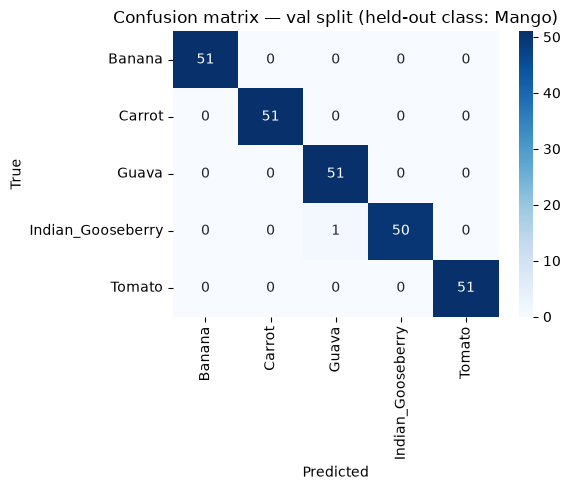

In [23]:
@torch.no_grad()
def predict(loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_preds, all_labels = [], []
    for pixel_values, labels in tqdm(loader, desc="predicting", leave=False):
        logits = model(pixel_values.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


val_preds, val_true = predict(val_loader)

acc = accuracy_score(val_true, val_preds)
macro_f1 = f1_score(val_true, val_preds, average="macro")
weighted_f1 = f1_score(val_true, val_preds, average="weighted")

print(f"Accuracy:    {acc:.4f}")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")
print(classification_report(val_true, val_preds, target_names=KNOWN_CLASSES, digits=3))

cm = confusion_matrix(val_true, val_preds, labels=range(len(KNOWN_CLASSES)))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=KNOWN_CLASSES, yticklabels=KNOWN_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix — val split (held-out class: {HELD_OUT_CLASS})")
plt.tight_layout()
plt.show()

## Embedding extraction (feature-embeddings merge point)

Pooled `[CLS]` embeddings for the known-class validation set and the held-out OOD
class, cached to disk. These are what the downstream energy-score / MSP /
prototype-distance scorers will consume once that stage is implemented.

In [12]:
@torch.no_grad()
def collect_embeddings(loader: DataLoader, desc: str = "") -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    embeddings, labels = [], []
    for pixel_values, batch_labels in tqdm(loader, desc=desc, leave=False):
        pixel_values = pixel_values.to(DEVICE)
        emb = model.get_embeddings(pixel_values)
        embeddings.append(emb.cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)


val_embeddings, val_labels = collect_embeddings(val_loader, desc="val embeddings")
ood_embeddings, _ = collect_embeddings(ood_loader, desc="OOD embeddings")

print(f"Val embeddings: {val_embeddings.shape}")
print(f"OOD embeddings: {ood_embeddings.shape}  (held-out class: {HELD_OUT_CLASS})")

np.save(NOTEBOOK_DIR / "vit_val_embeddings.npy", val_embeddings)
np.save(NOTEBOOK_DIR / "vit_val_labels.npy", val_labels)
np.save(NOTEBOOK_DIR / "vit_ood_embeddings.npy", ood_embeddings)

Val embeddings: (255, 768)
OOD embeddings: (150, 768)  (held-out class: Mango)


## Attention smoke test

Confirms attention weights are retrievable in the shape attention-rollout will need
later: one `(batch, heads, tokens, tokens)` tensor per transformer layer.

In [13]:
sample_pixel_values, _ = next(iter(val_loader))
attentions = model.get_attentions(sample_pixel_values[:2].to(DEVICE))
print(f"{len(attentions)} attention layers, each shaped {tuple(attentions[0].shape)}  (batch, heads, tokens, tokens)")

12 attention layers, each shaped (2, 12, 197, 197)  (batch, heads, tokens, tokens)


## Next steps

- Rotate `HELD_OUT_CLASS` across all 6 classes and aggregate results (standard
  leave-one-class-out protocol).
- Build the Supervised CNN and SSL-pretrained CNN (SimCLR/DINOv2) backbones so all
  three feed the same embedding space.
- Implement attention rollout on `get_attentions` output, and Grad-CAM for the CNN
  backbones, to compare explainability signals.
- Implement the energy score, MSP, and prototype-distance OOD scorers on top of the
  cached `vit_val_embeddings.npy` / `vit_ood_embeddings.npy`, and the decision-layer
  threshold sweep (AUROC, FPR@95).
- Consider unfreezing the backbone (`FREEZE_BACKBONE = False`) for a full fine-tuning
  ablation once the linear-probe baseline above is established.